## Exponentially Weighted Moving Average
Moving Average is an average that keeps getting updated after a fixed period.  
EWMA is a type of moving average where recent observations are given more importance, and older observations receive exponentially decreasing weights.

Formula

$$V_t = \beta V_{t-1} + (1-\beta) \theta_t $$

- $V_t$ is ewma for $t_{th}$ instance. $V_0$ = $0$ or $\theta_1$
- $\beta$ is a parameter.
    - _More the value of beta --> More the importance to previous data points_
    - Range of $\beta$ = (0 to 1)
- $\theta$ is the instance 

It is used for finding patterns and smoothing in time series data

It is used in:
- Time Series forecasting
- Financial forecasting
- Signal processing
- Deep learning

Intuition behind $\beta$: 
- More the value of beta --> More the importance to previous data points  

How? (Try doing some maths yourself and you'll get this result)
$$
V_4 = ( 1 - \beta )[ \beta^3 \theta_1 + \beta^2 \theta_2 + \beta \theta_3 +  \theta_4]
$$

hence clearly, initial values of theta (data) gets less weights in ewma

- Effect of $\beta$:    
it is observed that if you take $\beta$ then ewma acts like simple average of previous $\frac{1}{1-\beta}$ instances  
Example: if $\beta = 0.9$ then ewma will act like normal avg of previous $\frac{1}{1-0.9}=10$ instances

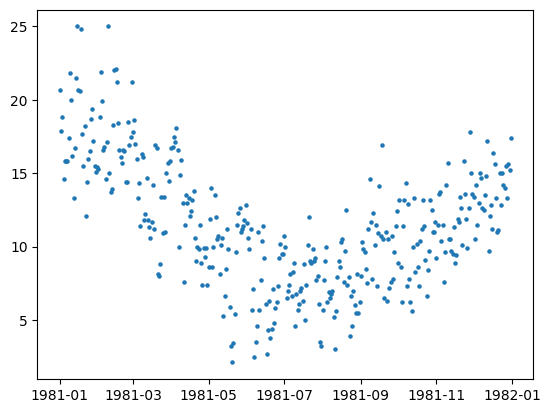

In [ ]:
## How it looks
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("datasets/daily-minimum-temperatures-in-me.csv")
data['Date'] = pd.to_datetime(data['Date'])
plt.scatter(data['Date'],data['Daily minimum temperatures'],s=5)

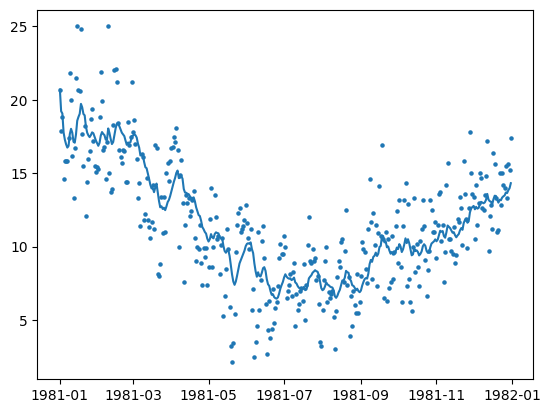

In [ ]:
data['EWMA'] = data['Daily minimum temperatures'].ewm(alpha=0.1).mean()  #alpha = 1-beta
plt.scatter(data['Date'],data['Daily minimum temperatures'],s=5)
plt.plot(data['Date'],data['EWMA'])

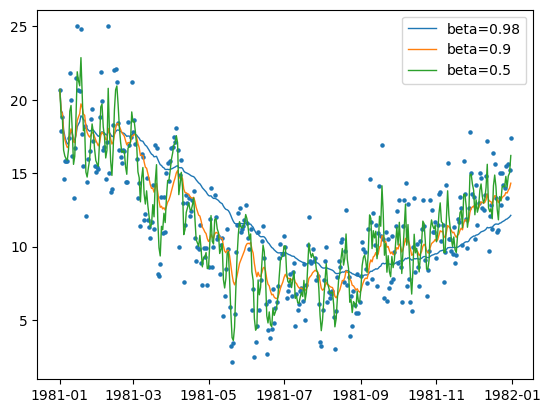

In [126]:
data['EWMA_0.98'] = data['Daily minimum temperatures'].ewm(alpha=0.02).mean()  
data['EWMA_0.9'] = data['Daily minimum temperatures'].ewm(alpha=0.1).mean() 
data['EWMA_0.5'] = data['Daily minimum temperatures'].ewm(alpha=0.5).mean()  

plt.scatter(data['Date'],data['Daily minimum temperatures'],s=5)
plt.plot(data['Date'],data['EWMA_0.98'], label="beta=0.98",linewidth=1)
plt.plot(data['Date'],data['EWMA_0.9'], label="beta=0.9",linewidth=1)
plt.plot(data['Date'],data['EWMA_0.5'], label="beta=0.5",linewidth=1)

plt.legend()

You can see that, more the value of beta (or less the value of alpha) 
- Gives more importance to previous data points
- Smoother curve